In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

# Bivariate analysis - 2 qualitative variables

*Example*

Lets say we want to know wether woman and men (within the same sample) responded differently to survey question

if the propotions of the answers (1-5) are the same for men and women there is no association between the two variables. If there are significant difference's there is.


**Input data**

In [2]:
# Read dataset + data preparation
rlanders = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-en-labs/main/data/rlanders.csv').set_index(['ID'])
rlanders.Gender = rlanders.Gender.astype('category')
likert_scale = CategoricalDtype(categories=[1,2,3,4,5], ordered=True)
rlanders.Survey = rlanders.Survey.astype(likert_scale)
# rlanders.info()
# rlanders.Survey.dtype

**Calculate a contingency table**

In [8]:
pd.crosstab(rlanders.Survey, rlanders.Gender, margins=True)

Gender,Female,Male,All
Survey,,,
1,0,4,4
2,17,45,62
3,23,91,114
4,12,53,65
5,0,5,5
All,52,198,250


**Generate a clustered bar chart**

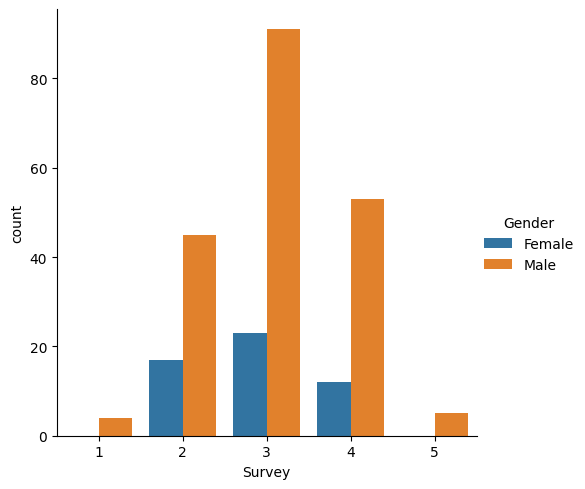

In [9]:
sns.catplot(data=rlanders, x='Survey', hue='Gender', kind='count');

Since there is a simular distribution we can conclude there is **no** association between the two variables

*If the distribution where to be different (e.g. highest peak for men at 2 and for women at 4) that would indicate a association or that men and woman give significantly different answers*

The only outlier in this example is that woman did not give extreme answers (1 or 5) but since the sample contains significantly fewer woman this may be a coincidence and not necessarily a siginifcant patern

**Alternative plot -> Stacked bar chart**

*Note seaborn does not offer  a convenient method so we use the plot method of the Panda dataframe (crosstab)*

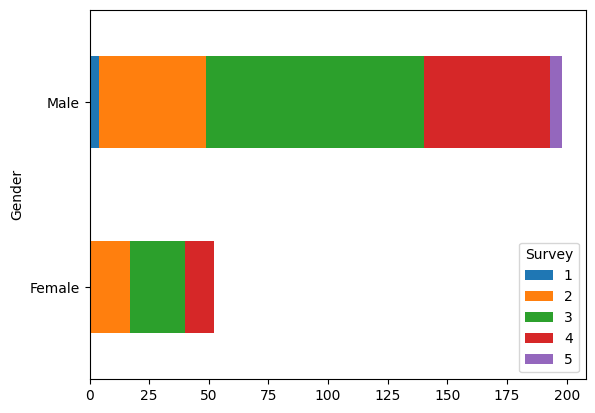

In [10]:
# Contingency table without the margins
observed = pd.crosstab(rlanders.Gender, rlanders.Survey)

# Horizontally oriented stacked bar chart
observed.plot(kind='barh', stacked=True);

This is essentialy the same information but it is noticable that there are way fewer female participants, in this case we can use *relative* frequencies (percentages)

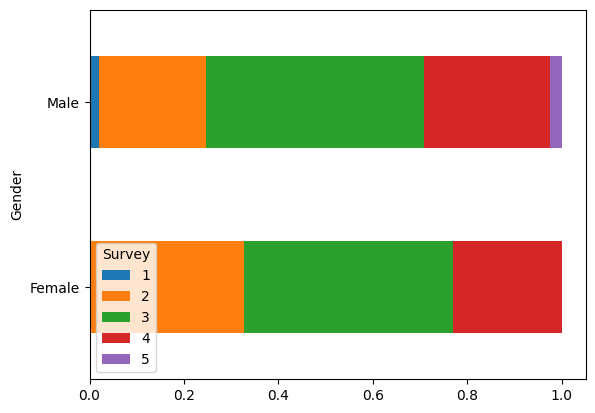

In [11]:
# Contingency table without the margins
observed_p = pd.crosstab(rlanders.Gender, rlanders.Survey, normalize='index')

# Horizontally oriented stacked bar chart
observed_p.plot(kind='barh', stacked=True);

In this representations the percentage of woman answering "2" seems larger than men (not enough to confirm significant patern).

We also lose the information that there are a lot less female then male participants. These issues can be fixed with a Mosaic diagram

## Mosaic Diagram

A mosaic diagram is a visual representation of the crosstab

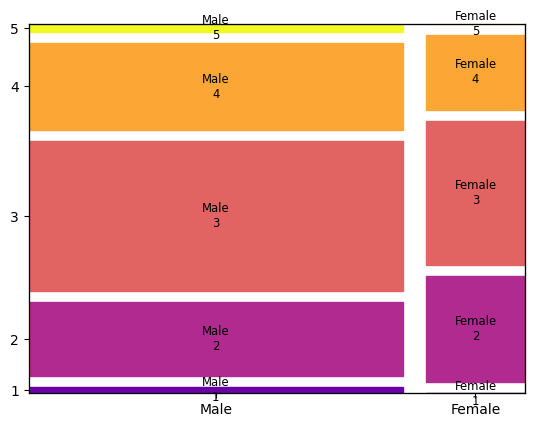

In [12]:
import matplotlib as mpl

# By default, mosaic() will color all columns the same. Here,
# we're going to give a separate color to each response (1-5).
# The response is kept in the label of each cell, a tuple of
# the two values that are represented in that cell (e.g. 
# ('Female', '2')). We will be using the "plasma" color map
# in this example.
plasma_colors = mpl.colormaps['plasma']
# Create a function that maps the cell key to the color we
# want to give it. We use the colormap function created above
# and give it a number between 0 and 1. We convert the second
# part of the key (values '1' to '5') to a number and divide
# by 5.
props = lambda key: {'color': plasma_colors(int(key[1])/5)}

mos_gender_survey = mosaic(
       data=rlanders.sort_values(by=['Survey']),
       index=['Gender', 'Survey'],
       gap=0.05, properties=props);

As we can see in the plot above the width signicies the amount of male/female participants while the height shows the ratings (1-5) both genders have given.

*At first sight the distrubutions seems to match quite well*

## Chi-squared and Cramér's V

Now the fun stuff using these statistics we can determine whether there is an association between two qualative (categorical) values.

**Steps**

1. Forumalate the hypotheses
   - $H_0$: There is no association between the variables (the differences between observed and expected values are small)
   - $H_1$: There is an association between the variables (the differences are large)
2. Choose significance level $\alpha$
3. Calculate the value of the test statistic in the sample (here: $\chi^2$).
4. Use one of the following methods (based on the degrees of freedom $df = (r-1) \times (k-1)$):
   - Determine critical value $g$ so $P(\chi^2 > g) = \alpha$
   - Calculate the $p$-value
5. Draw a conclusion based on the outcome:
   - $\chi^2 < g$: do not reject $H_0$; $\chi^2 > g$: reject $H_0$
   - $p > \alpha$: do not reject $H_0$; $p < \alpha$: reject $H_0$

In [4]:
# Chi-squared test for independence based on a contingency table
observed = pd.crosstab(rlanders.Survey, rlanders.Gender)
chi2, p, df, expected = stats.chi2_contingency(observed)

print("Chi-squared       : %.4f" % chi2)
print("Degrees of freedom: %d" % df)
print("P-value           : %.4f" % p)

Chi-squared       : 4.2555
Degrees of freedom: 4
P-value           : 0.3725


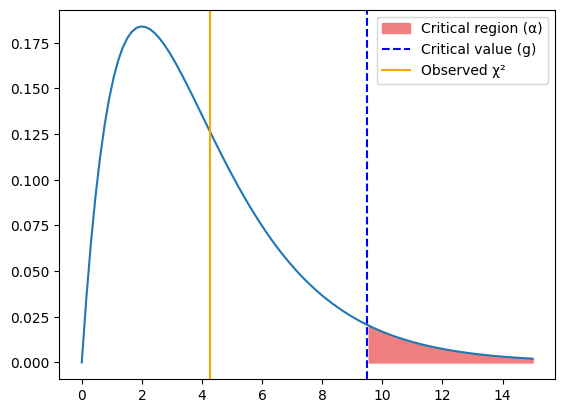

In [5]:
alpha = .05
dimensions = observed.shape
# Is there an association between Gender and Survey?
dof = (dimensions[0]-1) * (dimensions[1]-1)


# x-values:
x = np.linspace(0, 15, num=100)
# probability density of the chi-squared distribution with 4 degrees of freedom
y = stats.chi2.pdf(x, df=dof)
# the number q for which the right tail probability is exactly 5%:
q = stats.chi2.isf(alpha, df=4)  # TODO: CHECK this!

fig, tplot = plt.subplots(1, 1)
tplot.plot(x, y)                     # probability density
# Highlight the critical area and add vertical lines for the critical value and observed chi-squared.
tplot.fill_between(x, y, where=x>=q, color='lightcoral', label='Critical region (α)')  # critical area
tplot.axvline(q, color='blue', linestyle='--', label='Critical value (g)')            # critical value
tplot.axvline(chi2, color='orange', linestyle='-', label='Observed χ²')               # chi-squared

tplot.legend()  # Show

In this case we can see that the chi-value (χ²) falls well outside the critical region and p-value is smaller than $\alpha$. Meaning there is no significant difference between woman's and men's answers

## Goodness-of-fit test



**Example**

Suppose we have a sample of superheroes we keep track of, including the type and how often this type occurs in the entire population. Given below are the absolute frequencies in the sample $o_i$ and the expected relative frequencies $\pi_i$ in the population:

In [6]:
types =               ['mutant', 'human', 'alien', 'god', 'demon']
observed =   np.array([   127,      75,      98,     27,     73])
expected_p = np.array([   .35,     .17,     .23,    .08,    .17])

1. Formulate the hypotheses:
   - $H_0$: The sample is representative of the population, i.e. the frequency of each class within the sample corresponds well to that in the population. (**Nothing unusual here” — your sample looks like a miniature version of the whole population, with roughly the same mix of types.**)
   - $H_1$: The sample is *not* representative of the population, i.e. the differences with the expected frequencies are too large. (**“Something’s off” — the mix in your sample is different enough from the population proportions that it’s unlikely to be just random chance.**)
2. Choose significance level $\alpha$
3. Calculate the value of the test statistic in the sample (here: $\chi^2$).
4. Use one of the following methods (based on the degrees of freedom $df = (k-1)$ with $k$ the number of categories in the sample):
   1. Determine critical value $g$ so $P(\chi^2 > g) = \alpha$
   2. Calculate the $p$-value
5. Draw a conclusion based on the outcome:
   1. $\chi^2 < g$: do not reject $H_0$; $\chi^2 > g$: reject $H_0$
   2. $p > \alpha$: do not reject $H_0$; $p < \alpha$: reject $H_0$

A plot of this case, including the calculation of $p$ and $g$:

In [7]:
alpha = 0.05               # Significance level
n = sum(observed)          # Sample size
k = len(observed)          # Number of categories
dof = k - 1                # Degrees of freedom
expected = expected_p * n  # Expected absolute frequencies in the sample
g = stats.chi2.isf(alpha, df=dof)  # Critical value

# Goodness-of-fit-test in Python:
chi2, p = stats.chisquare(f_obs=observed, f_exp=expected)

print("Significance level  ⍺ = %.2f" % alpha)
print("Sample size         n = %d" % n)
print("k = %d; df = %d" % (k, dof))
print("Chi-squared        χ² = %.4f" % chi2)
print("Critical value      g = %.4f" % g)
print("p-value             p = %.4f" % p)

Significance level  ⍺ = 0.05
Sample size         n = 400
k = 5; df = 4
Chi-squared        χ² = 3.4679
Critical value      g = 9.4877
p-value             p = 0.4828


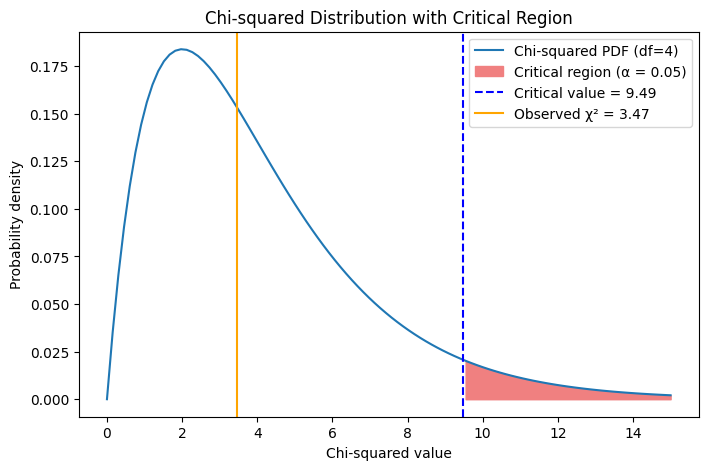

In [14]:
# Plot of the chi-squared distribution
x = np.linspace(0, 15, num=100)
y = stats.chi2.pdf(x, df=dof)

# Critical value where right-tail area = alpha
q = stats.chi2.isf(alpha, df=dof)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, label=f'Chi-squared PDF (df={dof})')

# Shade critical region
ax.fill_between(x, y, where=x >= q, color='lightcoral', label=f'Critical region (α = {alpha})')

# Draw critical value line
ax.axvline(q, color='blue', linestyle='--', label=f'Critical value = {q:.2f}')

# Draw observed test statistic
ax.axvline(chi2, color='orange', linestyle='-', label=f'Observed χ² = {chi2:.2f}')

# Labels and title
ax.set_xlabel('Chi-squared value')
ax.set_ylabel('Probability density')
ax.set_title('Chi-squared Distribution with Critical Region')

ax.legend()
plt.show()

In this case once again the observer X2 value falls well outside of the critical region. Meaning we accept H0 

## Standardised residuals

After performing a chi-squared test, it is often also interesting to know in which categories the largest deviations occur. We do this using the *standardised residuals*

**Example**

A study looks at families with 5 children. A sample of 1022 samples is taken, divided into categories accoring to number of boys in the family.

In [21]:
# Data frame with 2 columns:
#  - number of boys in the family (index)
#  - number of families in the sample with that number of boys
families = pd.DataFrame(
    np.array(
        [[0,  58],
         [1, 149],
         [2, 305],
         [3, 303],
         [4, 162],
         [5,  45]]),
    columns=['num_boys', "observed"])
families.set_index(['num_boys'])
n = families.observed.sum() # sample size

from scipy.special import binom # binomial-function

# -----------
# Lets assume getting a boy is a 0.5 (50%) in that case we calculate
# the expected relative frequencies
# ----------


# probability for a boy
prob_boy = .5
# Add new colum to the data frame for the expected percentages
families['expected_p'] = binom(5, families.num_boys) * prob_boy**families.num_boys * prob_boy**(5-families.num_boys)
# Expected absolute frequencies in the sample:
families['expected'] = families['expected_p'] * n
print(f"{families}\n")

# ----------
# Perform chi-squared goodness-of-fit test with a significance level (alpha) of 0.01
# ----------

alpha=0.01                         # significance level
dof=len(families)-1                # degrees of freedom
g = stats.chi2.isf(alpha, df=dof)  # Critical value
# Perform Chi-squared test, calculate χ² and p
chi2, p = stats.chisquare(f_obs=families.observed, f_exp=families.expected)

print("Chi-squared   χ² = %.4f" % chi2)
print("Critical value g = %.4f" % g)
print("p-value        p = %f"   % p)

   num_boys  observed  expected_p  expected
0         0        58     0.03125   31.9375
1         1       149     0.15625  159.6875
2         2       305     0.31250  319.3750
3         3       303     0.31250  319.3750
4         4       162     0.15625  159.6875
5         5        45     0.03125   31.9375

Chi-squared   χ² = 28.8462
Critical value g = 15.0863
p-value        p = 0.000025


*Since this is a very small p-value and the chi-squared is also to the right of the critical value we can reject the the null hypothesis (falls within the critical region)

A plot:

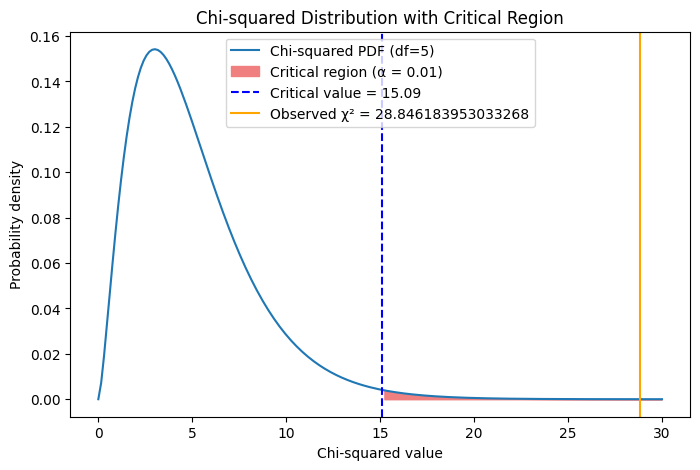

In [ ]:
# x-values for smooth curve
x = np.linspace(0, 30, num=200)
# PDF of chi-squared distribution
y = stats.chi2.pdf(x, df=dof)
# Critical value where right-tail area = alpha
q = stats.chi2.isf(alpha, df=dof)

# Create plot
fig, tplot = plt.subplots(figsize=(8, 5))
tplot.plot(x, y, label=f'Chi-squared PDF (df={dof})')

# Shade the critical region
tplot.fill_between(x, y, where=x >= q, color='lightcoral', label=f'Critical region (α = {alpha})')

# Vertical line for critical value
tplot.axvline(q, color='blue', linestyle='--', label=f'Critical value = {q:.2f}')

# Vertical line for observed chi-squared statistic
tplot.axvline(chi2, color='orange', linestyle='-', label=f'Observed χ² = {chi2}')

# Labels and title
tplot.set_title('Chi-squared Distribution with Critical Region')
tplot.set_xlabel('Chi-squared value')
tplot.set_ylabel('Probability density')

# Show legend
tplot.legend()

We conclude that this sample is NOT representative for the population!

The formula for calculating standardised residuals is:

$r_i = \frac{o_i-e_i}{\sqrt{e_i (1-\pi_i)}}$

We will add these to our data frame in a new column:

In [25]:
families['stdres'] = (families.observed - families.expected) / np.sqrt(families.expected * (1 - families.expected_p))
families

,num_boys,observed,expected_p,expected,stdres
0,0,58,0.03125,31.9375,4.685541
1,1,149,0.15625,159.6875,-0.920733
2,2,305,0.31250,319.3750,-0.970110
3,3,303,0.31250,319.3750,-1.105082
4,4,162,0.15625,159.6875,0.199223
5,5,45,0.03125,31.9375,2.348389


Standardised residuals are a measure of the extent to which a certain category is over- or under-represented in the sample. A value of 0 is given when the observed frequency is equal to the expected frequency. A negative value is given when there are fewer observations than expected and a positive value when there are more. As long as $r_i \in [-2, 2]$, we consider the differences to be random sampling errors. A value $r_i < -2$ indicates underrepresentation of this category, $r_i > 2$ indicates overrepresentation.


Thus, families with only girls and only boys are over-represented in the sample. In practice, researchers could choose to randomly remove a number of observations in these categories from the study, so that the sample becomes representative of the population.

## Cochran's rule

A chi-squared test can only give good results if you have enough observations in each category. The statistician Cochran (1954) formulated a rule of thumb to determine what exactly *enough* is on contingency tables larger than 2x2:

- All expected values must be at least 1
- At most 20% of the expected values may be smaller than 5

## Refining data + Basics

**Example** 
114/250 (0.456) have answered 3 since there are 52 females (52 x 0.456) = 23.712% females responded with 3

This is seen the the expected variable



In [13]:
observed = pd.crosstab(rlanders.Survey, rlanders.Gender)
row_sums = observed.sum(axis=1)
col_sums = observed.sum()
n = row_sums.sum()

print(row_sums) # Total of ratings of all respondents
print(col_sums) # Amount of responses per gender
print(f'Number of observations: {n}\n')

# Calculate expected values
# These are the expected of the amount of male/female responses to the survey
# See example above
expected = np.outer(row_sums, col_sums) / n
print(f"Expected values:\n {expected}\n")


# Check the margins again (essentialy the same data as first prints)
exp_row_sums = np.sum(expected, axis=1)
exp_col_sums = np.sum(expected, axis=0)

print(f'Row totals   : {exp_row_sums}')
print(f'Column totals: {exp_col_sums}')
print(f'Observations : {exp_col_sums.sum()}')



Survey
1      4
2     62
3    114
4     65
5      5
dtype: int64
Gender
Female     52
Male      198
dtype: int64
Number of observations: 250

Expected values:
 [[ 0.832  3.168]
 [12.896 49.104]
 [23.712 90.288]
 [13.52  51.48 ]
 [ 1.04   3.96 ]]

Row totals   : [  4.  62. 114.  65.   5.]
Column totals: [ 52. 198.]
Observations : 250.0


**Standard residuals table**

Values greater then 2 or less than -2 indicate a cell where observed count is much higher or lower than expected **suggesting** a possible significant difference

In [14]:
# Standard residuals table
expected - observed

Gender,Female,Male
Survey,,
1,0.832,-0.832
2,-4.104,4.104
3,0.712,-0.712
4,1.520,-1.520
5,1.040,-1.040


In this table we can clearly see that all values except 2 fall well within the treshhold (-2 or +2).

### Calculate chi-squared

$\chi^2 = \sum_i \frac{(o_i - e_i)^2}{e_i}$

In [20]:
diffs = (expected - observed)**2 / expected
print(diffs) # Square the differences between expected and observed values (Total deviations)

chi_squared = diffs.values.sum()
print('χ² ≈ %.3f' %chi_squared)

Gender    Female      Male
Survey                    
1       0.832000  0.218505
2       1.306050  0.343003
3       0.021379  0.005615
4       0.170888  0.044880
5       1.040000  0.273131
χ² ≈ 4.255


This value alone still does not say very much, but we use this value to calculate Cramérs V that normalizes χ² befdore you can conclude wheter there is a association



## Cramer's V

$V = \sqrt{\frac{\chi^2}{n(k-1)}}$

In [16]:
dof = min(observed.shape) - 1
cramers_v = np.sqrt(chi_squared / (dof * n))
print(cramers_v)

0.13046762087242633


To draw a conclusion from this figure, compare it with the values in the table below:

| Cramér's V | Interpretation          |
| :---:      | :---                    |
| 0          | No association          |
| 0.1        | Weak association        |
| 0.25       | Moderate association    |
| 0.50       | Strong association      |
| 0.75       | Very strong association |
| 1          | Complete association    |

## The chi-squared test for independence

To answer the question of when the value of the chi-square is sufficient to assume an association between two variables we use the chi-square independence test.

# The chi-squared distribution

This plots the probability density function of The value $\chi^2$ -distribution for a number of degrees of freedom (df).

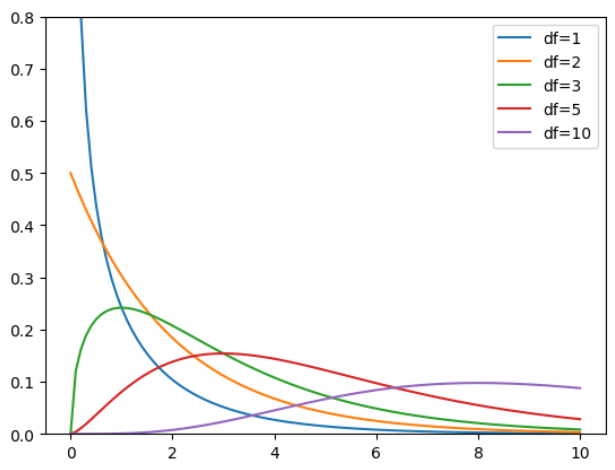

<details>

<summary>Show Graph code</summary>

```python
# Plot of the chi-squared distribution for different degrees of freedom
x = np.linspace(0, 10, num=100)
fig, tplot = plt.subplots(1, 1);
tplot.set_ylim([0, 0.8]);
tplot.plot(x, stats.chi2.pdf(x, 1), label="df=1");
tplot.plot(x, stats.chi2.pdf(x, 2), label="df=2");
tplot.plot(x, stats.chi2.pdf(x, 3), label="df=3");
tplot.plot(x, stats.chi2.pdf(x, 5), label="df=5");
tplot.plot(x, stats.chi2.pdf(x, 10), label="df=10");
tplot.legend(loc='best');
```

</details>

Using this figure you can follow a reasoning simular to a right-sides z-test and calculate a critical value g for which the area of the right of g is equal to our chosen significance level $\alpha$. If the test statistic $\chi^2$ is greater than $g$, we say that the deviations from the expected values in the contingency table are too large to be coincidental and that we have reason to believe that there is an association between the two variables.

Here we calculate the excess probability p i.e the probability that the deviations you see in the sample could be due to random sampling errors.

**We calculate the area under the density curve to the right of p, if this area is smaller than $\alpha$

In Python, we use the following Scipy functions for this purpose:

- `stats.chi2.sf(x)` - the right tail probability of `x` (or survival function)
- `stats.chi2.isf(q)` - the inverse function of `sf(x)`, i.e. calculate a number `x` for which the right tail probability is exactly `q`.

A plot for the case where $\alpha = 0.05$ (an often chosen value for the significance level) and 4 degrees of freedom:

In [1]:
# Right tail probability in the chi-squared distribution

# x-values:
x = np.linspace(0, 15, num=100)
# probability density of the chi-squared distribution with 4 degrees of freedom
y = stats.chi2.pdf(x, df=4)
# the number q for which the right tail probability is exactly 5%:
q = stats.chi2.isf(.05, df=4)

fig, tplot = plt.subplots(1, 1)
tplot.plot(x, y)                      # probability density
tplot.fill_between(x, y, where=x>=q,  # critical area
    color='lightblue')
tplot.axvline(q);                     # critical value

NameError: name 'np' is not defined